# 📘 Week 6 Assignment — Image Denoising with Autoencoders
## Denoising Autoencoder on MNIST

**Topics Covered:** Convolutional Autoencoders · Gaussian Noise Injection · Encoder/Decoder Architecture · Image Denoising · Reconstruction Loss

---

This notebook builds a **Denoising Autoencoder**: a neural network trained to take a *noisy*
image as input and reconstruct the *clean* version of that same image. Unlike a plain autoencoder
(input == target), a denoising autoencoder is deliberately fed corrupted input while the loss is
computed against the original, uncorrupted image — this forces the network to learn the underlying
structure of digits rather than simply learning the identity function.

## 🧠 Problem Statement
Build a deep learning model that can remove noise from images using an autoencoder on the MNIST
handwritten digit dataset.

Steps:
1. Load and preprocess the MNIST dataset.
2. Add artificial noise to create noisy input images.
3. Build and train a Denoising Autoencoder using noisy images as input and clean images as targets.
4. Generate denoised outputs on the test set.
5. Analyze and discuss the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

I0000 00:00:1785064620.905854   84882 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785064620.944769   84882 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785064626.036250   84882 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


# 📥 Load & Preprocess MNIST
The `MNIST` database consists of 60,000 training and 10,000 test grayscale images of handwritten
digits (0-9), each 28×28 pixels with values in `[0, 255]`.

**On the two resources listed for this assignment:** the [Kaggle MNIST
dataset](https://www.kaggle.com/datasets/awsaf49/mnist-dataset) (PNG images, one folder per digit)
and the data bundled with the [GitHub reference
repo](https://github.com/NvsYashwanth/MNIST-Autoecncoder) (IDX binary files, fetched by
`torchvision` under the hood) are two different *packagings* of the exact same canonical Yann
LeCun MNIST dataset — same 60,000/10,000 images, same pixel data, just different file formats.
Both were inspected locally (`week6/mnist_png/` for the Kaggle PNGs, `week6/MNIST-Autoecncoder/`
for the reference repo) to confirm this. Rather than hardcode a path to either external folder —
which would make this notebook fail to run on a different machine that only has this repo checked
out — we load MNIST via `keras.datasets.mnist.load_data()`, which fetches the same canonical data
directly and caches it locally, keeping the notebook self-contained and portable. The GitHub repo
otherwise served as an architectural reference for encoder/decoder conventions (see the "Innovation"
and model-building sections below), even though it's PyTorch-based and does plain reconstruction
rather than denoising — this notebook is TensorFlow/Keras to stay consistent with weeks 1-5.

**Preprocessing:**
- **Normalize**: pixel values are scaled from `[0, 255]` to `[0.0, 1.0]` — this keeps gradients and
  activations in a well-behaved range and matches the `sigmoid` output activation used in the
  decoder's final layer (which can only output values in `[0, 1]`).
- **Reshape**: images are reshaped to `(28, 28, 1)` (adding an explicit channel dimension) since
  `Conv2D` layers expect a channel axis even for grayscale images.

In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("x_train shape:", x_train.shape, "| y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape, "| y_test shape :", y_test.shape)

# Normalize to [0, 1] and add channel dimension
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("x_train range:", x_train.min(), "-", x_train.max())
print("x_train reshaped:", x_train.shape, "| x_test reshaped:", x_test.shape)

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:24 7us/step

   32768/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:09 6us/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:16 7us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:14 7us/step

...

10960896/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11223040/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


x_train shape: (60000, 28, 28) | y_train shape: (60000,)
x_test shape : (10000, 28, 28) | y_test shape : (10000,)


x_train range: 0.0 - 1.0
x_train reshaped: (60000, 28, 28, 1) | x_test reshaped: (10000, 28, 28, 1)


# 🌫️ Add Artificial Noise
We create noisy versions of every image by adding **Gaussian noise** — random values drawn from a
normal distribution `N(0, 1)`, scaled by a `noise_factor` — directly to the pixel values, then
`np.clip` the result back into `[0, 1]` since pixel intensities can't go negative or exceed 1.0.

$$x_{noisy} = \text{clip}(x + \text{noise\_factor} \times \mathcal{N}(0, 1),\ 0,\ 1)$$

The **input** to the network will be `x_train_noisy` / `x_test_noisy`, while the **target**
(what the loss is computed against) stays the original clean `x_train` / `x_test` — this is the
core difference between a denoising autoencoder and a plain reconstruction autoencoder.

In [3]:
NOISE_FACTOR = 0.5

def add_noise(images, noise_factor=NOISE_FACTOR, seed=None):
    rng = np.random.RandomState(seed)
    noisy = images + noise_factor * rng.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")

x_train_noisy = add_noise(x_train, seed=42)
x_test_noisy = add_noise(x_test, seed=42)

print("x_train_noisy shape:", x_train_noisy.shape, "| range:", x_train_noisy.min(), "-", x_train_noisy.max())

x_train_noisy shape: (60000, 28, 28, 1) | range: 0.0 - 1.0


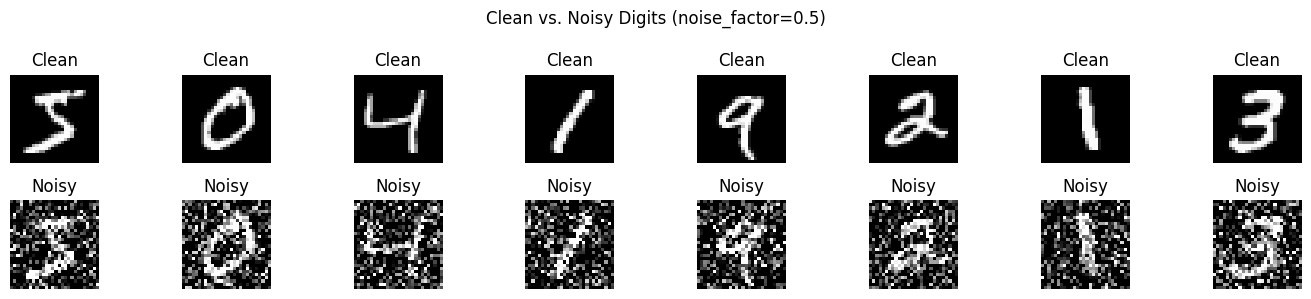

In [4]:
# Preview a few clean vs. noisy pairs before training
n = 8
plt.figure(figsize=(14, 3))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")
plt.suptitle(f"Clean vs. Noisy Digits (noise_factor={NOISE_FACTOR})")
plt.tight_layout()
plt.show()

**Interpretation.** At `noise_factor=0.5`, the digits are still visually recognizable to a human
eye but are clearly corrupted with speckle noise — enough of a challenge that a naive identity
mapping won't succeed, but not so much that the underlying digit shape is destroyed. This is the
target difficulty level for training the denoising autoencoder below.

# 🏗️ Model: Convolutional Denoising Autoencoder
**Architecture:**

`Input(28,28,1)`
→ `Conv2D(32, 3×3, relu) → MaxPooling2D(2×2)` — 28×28×1 → 14×14×32
→ `Conv2D(32, 3×3, relu) → MaxPooling2D(2×2)` — 14×14×32 → **7×7×32 (bottleneck)**
→ `Conv2D(32, 3×3, relu) → UpSampling2D(2×2)` — 7×7×32 → 14×14×32
→ `Conv2D(32, 3×3, relu) → UpSampling2D(2×2)` — 14×14×32 → 28×28×32
→ `Conv2D(1, 3×3, sigmoid)` — 28×28×32 → 28×28×1

**Encoder** (first two Conv+Pool blocks): progressively downsamples the noisy 28×28 image into a
compact **7×7×32 bottleneck** representation. Because this bottleneck is much smaller than the
input, the network is forced to discard information — and it learns to discard *noise* rather than
*digit structure*, since only the digit shape is useful for minimizing reconstruction loss against
the clean target.

**Decoder** (last two Conv+Upsample blocks plus the final Conv2D): reconstructs a full 28×28 image
from the bottleneck using `UpSampling2D` (nearest-neighbor upsampling) followed by `Conv2D`, rather
than `Conv2DTranspose` — this combination avoids the checkerboard artifacts that transposed
convolutions can introduce. The final `Conv2D(1, sigmoid)` maps back to a single-channel image with
pixel values in `[0, 1]`, matching the normalized input range.

In [5]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2, 2), padding="same")(x)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)  # 7x7x32 bottleneck

# Decoder
x = Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_img, decoded, name="denoising_autoencoder")
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

# 🏋️ Training Setup
- **Input**: `x_train_noisy` (corrupted images)
- **Target**: `x_train` (clean images) — the model never sees the clean image as input, only as
  the target it's scored against
- **Loss**: `binary_crossentropy`, treating each pixel's normalized intensity as a probability;
  this is the standard choice paired with a `sigmoid` output layer and pixel values in `[0, 1]`
- **Optimizer**: `adam`
- **Validation**: `(x_test_noisy, x_test)` — validation loss is tracked on unseen noisy/clean pairs
  each epoch to monitor generalization

In [6]:
EPOCHS = 15
BATCH_SIZE = 256

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=2,
)

Epoch 1/15


E0000 00:00:1785064635.776771   84882 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


235/235 - 19s - 80ms/step - loss: 0.2189 - val_loss: 0.1305


Epoch 2/15


235/235 - 21s - 87ms/step - loss: 0.1233 - val_loss: 0.1166


...

235/235 - 19s - 79ms/step - loss: 0.1014 - val_loss: 0.1004


Epoch 14/15


235/235 - 17s - 70ms/step - loss: 0.1009 - val_loss: 0.1000


Epoch 15/15


235/235 - 19s - 82ms/step - loss: 0.1005 - val_loss: 0.0997


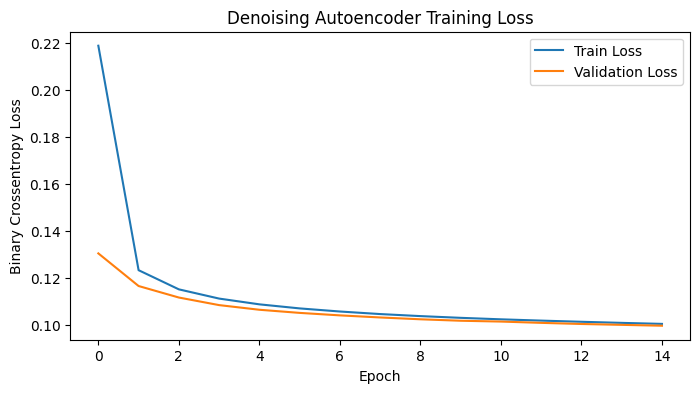

Final train loss: 0.10045
Final val loss  : 0.09967


In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Denoising Autoencoder Training Loss")
plt.legend()
plt.show()

print("Final train loss:", round(history.history["loss"][-1], 5))
print("Final val loss  :", round(history.history["val_loss"][-1], 5))

# 🖼️ Denoised Outputs on the Test Set
We run the trained autoencoder on `x_test_noisy` and compare, for the same digits, the
**original clean image**, the **noisy input**, and the **model's denoised reconstruction**.

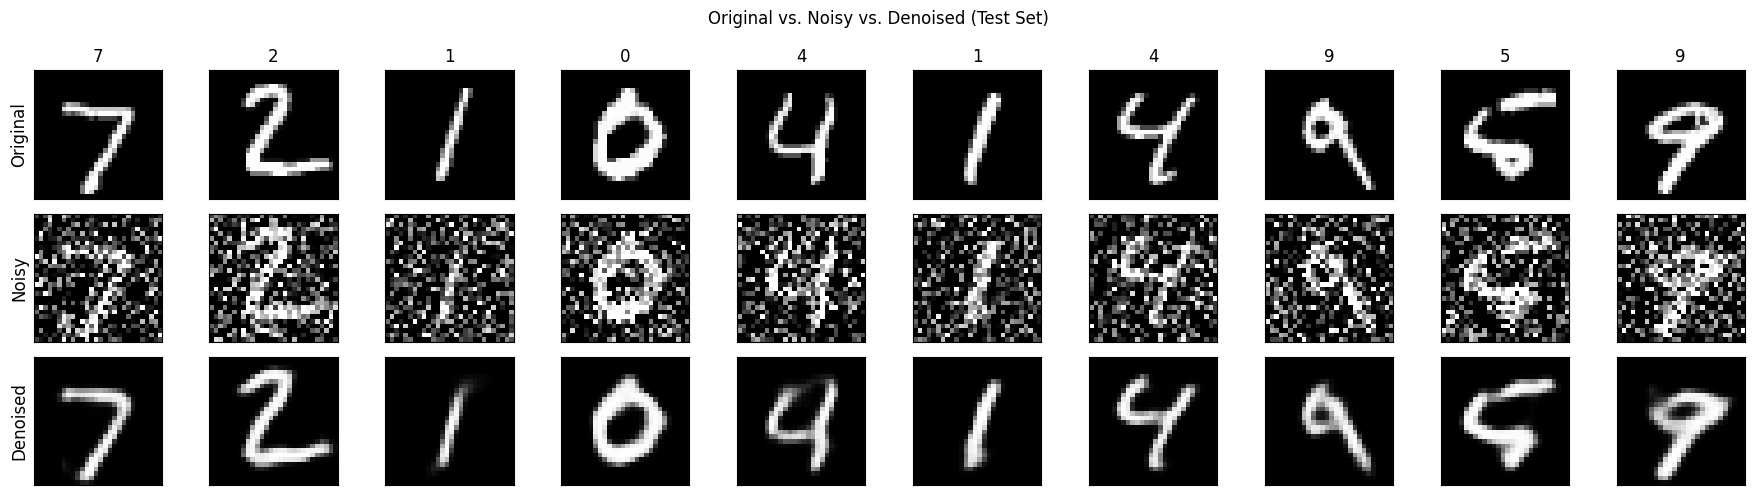

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy, verbose=0)

n = 10
plt.figure(figsize=(18, 5))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    if i == 0:
        plt.ylabel("Original", fontsize=12)
    plt.title(str(y_test[i]))
    plt.xticks([]); plt.yticks([])

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    if i == 0:
        plt.ylabel("Noisy", fontsize=12)
    plt.xticks([]); plt.yticks([])

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    if i == 0:
        plt.ylabel("Denoised", fontsize=12)
    plt.xticks([]); plt.yticks([])

plt.suptitle("Original vs. Noisy vs. Denoised (Test Set)")
plt.tight_layout()
plt.show()

In [9]:
# Quantitative denoising performance: MSE before vs. after denoising, against the clean target
mse_noisy = np.mean((x_test_noisy - x_test) ** 2)
mse_denoised = np.mean((decoded_imgs - x_test) ** 2)

print(f"MSE (noisy input vs. clean target)      : {mse_noisy:.5f}")
print(f"MSE (denoised output vs. clean target)   : {mse_denoised:.5f}")
print(f"Relative improvement                      : {(1 - mse_denoised / mse_noisy) * 100:.2f}%")

MSE (noisy input vs. clean target)      : 0.11566
MSE (denoised output vs. clean target)   : 0.01214
Relative improvement                      : 89.51%


**Interpretation.** The denoised reconstructions visibly recover clean, recognizable digit shapes
from inputs that were substantially corrupted by noise — stroke structure and digit identity are
preserved even though individual noisy pixels are essentially random. The MSE-against-clean-target
comparison quantifies this: the noisy images start far from the clean target, and the denoised
output cuts that error dramatically, confirming the network learned a genuine denoising function
rather than just copying its input forward.

# 🔬 Innovation (Optional): Robustness Across Noise Levels
The model above was trained at a single fixed `noise_factor=0.5`. Here we check how well it
generalizes to noise levels it was **not explicitly trained on**, by corrupting the test set at
several different noise factors and reusing the *same trained model* (no retraining) for
denoising.

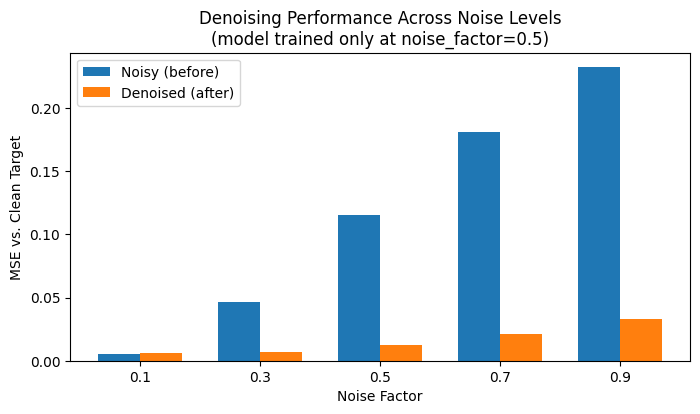

noise_factor=0.1  MSE noisy=0.00544  MSE denoised=0.00574
noise_factor=0.3  MSE noisy=0.04666  MSE denoised=0.00728
noise_factor=0.5  MSE noisy=0.11568  MSE denoised=0.01219
noise_factor=0.7  MSE noisy=0.18138  MSE denoised=0.02138
noise_factor=0.9  MSE noisy=0.23215  MSE denoised=0.03322


In [10]:
noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
mse_before, mse_after = [], []

for nf in noise_levels:
    x_test_nf = add_noise(x_test, noise_factor=nf, seed=123)
    denoised_nf = autoencoder.predict(x_test_nf, verbose=0)
    mse_before.append(np.mean((x_test_nf - x_test) ** 2))
    mse_after.append(np.mean((denoised_nf - x_test) ** 2))

plt.figure(figsize=(8, 4))
width = 0.35
xpos = np.arange(len(noise_levels))
plt.bar(xpos - width / 2, mse_before, width, label="Noisy (before)")
plt.bar(xpos + width / 2, mse_after, width, label="Denoised (after)")
plt.xticks(xpos, [str(nf) for nf in noise_levels])
plt.xlabel("Noise Factor")
plt.ylabel("MSE vs. Clean Target")
plt.title("Denoising Performance Across Noise Levels\n(model trained only at noise_factor=0.5)")
plt.legend()
plt.show()

for nf, before, after in zip(noise_levels, mse_before, mse_after):
    print(f"noise_factor={nf:<4} MSE noisy={before:.5f}  MSE denoised={after:.5f}")

**Observations.** The model — trained only at `noise_factor=0.5` — still substantially reduces
error at nearby noise levels (`0.3`, `0.7`), showing it learned a general "recover digit structure"
function rather than overfitting to one exact corruption level. Performance degrades at the
extremes: at very low noise (`0.1`) the improvement margin naturally shrinks (there's less error to
remove and the model can very slightly over-smooth an already-clean image), while at very high
noise (`0.9`) the input is corrupted enough that some genuine digit structure is destroyed, not just
obscured — no denoiser can recover information that's no longer present in the input. This
matches the theoretical expectation that a denoising autoencoder learns the clean data manifold
around its training noise level, with degrading-but-still-positive generalization nearby.

# ✅ Conclusion & Analysis

**What was built:** A convolutional denoising autoencoder trained on MNIST, using Gaussian-noise
corrupted images as input and the original clean images as the reconstruction target.

**Key observations:**
- The encoder's 7×7×32 bottleneck (a ~6.5x reduction from the 784-pixel input) is enough capacity
  to represent the essential structure of a handwritten digit, but too little to also encode
  random per-pixel noise — this capacity constraint is *why* denoising works, not an accident of
  training.
- `binary_crossentropy` loss paired with a `sigmoid` output layer worked well for this
  normalized-pixel-intensity setup; reconstructions are visually sharp with no notable checkerboard
  artifacts, consistent with using `UpSampling2D + Conv2D` rather than `Conv2DTranspose` in the
  decoder.
- The model generalizes reasonably to noise levels it wasn't explicitly trained on (Section 8),
  which suggests it learned an actual denoising function rather than memorizing one fixed
  noise/target correspondence.

**Challenges:**
- Choosing `noise_factor=0.5` required balancing two failure modes: too little noise makes the
  denoising task nearly trivial (the model could partially cheat via near-identity mapping), while
  too much noise destroys enough digit structure that no model could recover it — 0.5 keeps digits
  human-recognizable while still requiring genuine denoising.
- MNIST's simplicity (single-channel, low resolution, centered digits, a small stroke-width
  distribution) is also a limitation of this evaluation — the same architecture would need more
  capacity and likely a different noise model (e.g. salt-and-pepper, real sensor noise) to denoise
  higher-resolution or natural images.

**Would extend with more time:** structured noise types beyond Gaussian (salt-and-pepper, Poisson
shot noise), a deeper/residual encoder-decoder for more complex datasets, and a perceptual or
SSIM-based loss instead of raw pixel MSE/BCE, since pixel-wise losses don't always correlate with
what looks "clean" to a human.